In [3]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import seaborn as sns


# Import PCA
from sklearn.decomposition import PCA

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

In [4]:
# function to compute inertia score for various number of clusters

def kmeans_inertias(num_cluster, df_pca):
    inertias = []
    for c in num_cluster:
        km = KMeans(n_clusters=c, random_state=0).fit(df_pca)
        inertias.append(km.inertia_)
    return inertias

In [5]:
df = pd.read_csv("./wine-clustering.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [7]:
df_scaled = StandardScaler().fit_transform(df)

In [8]:
# Compare original vs scaled variance for each feature
import numpy as np
print('Feature	Original Variance	Scaled Variance')
for name, orig_var, scaled_var in zip(df.columns, df.var(), np.var(df_scaled, axis=0)):
    print(f'{name}	{orig_var:.2f}		{scaled_var:.2f}')

Feature	Original Variance	Scaled Variance
Alcohol	0.66		1.00
Malic_Acid	1.25		1.00
Ash	0.08		1.00
Ash_Alcanity	11.15		1.00
Magnesium	203.99		1.00
Total_Phenols	0.39		1.00
Flavanoids	1.00		1.00
Nonflavanoid_Phenols	0.02		1.00
Proanthocyanins	0.33		1.00
Color_Intensity	5.37		1.00
Hue	0.05		1.00
OD280	0.50		1.00
Proline	99166.72		1.00


In [9]:
import numpy as np
print('Variance of each feature in scaled dataset:')
for name, var in zip(df.columns, np.var(df_scaled, axis=0)):
    print(f"{name}: {var:.2f}")

Variance of each feature in scaled dataset:
Alcohol: 1.00
Malic_Acid: 1.00
Ash: 1.00
Ash_Alcanity: 1.00
Magnesium: 1.00
Total_Phenols: 1.00
Flavanoids: 1.00
Nonflavanoid_Phenols: 1.00
Proanthocyanins: 1.00
Color_Intensity: 1.00
Hue: 1.00
OD280: 1.00
Proline: 1.00


In [10]:
# Select numeric features
features = df.select_dtypes(include=[float, int]).columns
X = df[features]

# Fit PCA to determine number of components for 80% variance
pca_full = PCA()
pca_full.fit(df_scaled)
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
n_components_80 = (cumulative_variance >= 0.8).argmax() + 1

# Fit PCA with optimal number of components
pca_opt = PCA(n_components=n_components_80)
X_pca = pca_opt.fit_transform(X)

print(f'Number of components to explain at least 80% variance: {n_components_80}')
print(f'Shape of transformed data: {X_pca.shape}')

# Optionally, create a DataFrame for the reduced data
pca_wine_df = pd.DataFrame(X_pca, columns=[f'PCA {i+1}' for i in range(n_components_80)])
pca_wine_df.head()

Number of components to explain at least 80% variance: 5
Shape of transformed data: (178, 5)


,PCA 1,PCA 2,PCA 3,PCA 4,PCA 5
0,318.562979,21.492131,-3.130735,0.250114,-0.677078
1,303.097420,-5.364718,-6.822835,0.864035,0.486096
2,438.061133,-6.537309,1.113223,-0.912411,-0.380651
3,733.240139,0.192729,0.917257,0.541251,-0.858662
4,-11.571428,18.489995,0.554422,-1.360896,-0.276442


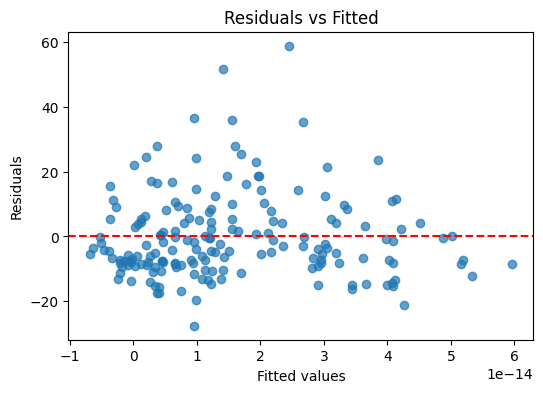

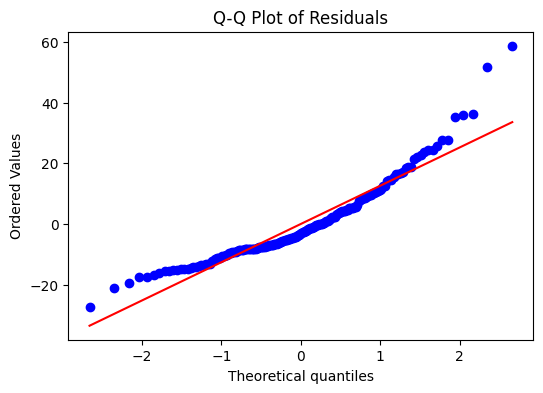

Shapiro-Wilk test statistic: 0.9092, p-value: 0.0000
Residuals are not normal (reject H0)


In [11]:
# --- Residual Diagnostics: Linearity, Homoscedasticity, Normality ---
# Example: Fit a linear regression to the first two principal components
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

# Use first two PCA components for demonstration
X_diag = pca_wine_df.iloc[:, :1] if 'pca_wine_df' in locals() else pd.DataFrame(X_pca[:, :1], columns=["PCA 1"])
y_diag = pca_wine_df.iloc[:, 1] if 'pca_wine_df' in locals() else X_pca[:, 1]

model = LinearRegression()
model.fit(X_diag, y_diag)
y_pred = model.predict(X_diag)
residuals = y_diag - y_pred

# Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Q-Q plot for normality
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

# Print Shapiro-Wilk test for normality
from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(residuals)
print(f'Shapiro-Wilk test statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}')
if shapiro_p > 0.05:
    print('Residuals appear normal (fail to reject H0)')
else:
    print('Residuals are not normal (reject H0)')

Loadings:
[[ 5.22607252e-01  1.58070625e-02  5.18388958e-02  3.16005481e-01
  -2.25442087e-02]
 [-2.14494809e-01  2.83062641e-02  3.74812822e-01  3.58325409e-01
   6.79401483e-01]
 [ 6.13881276e-02  6.03393829e-02  1.59713253e-01 -2.18333817e-02
  -2.23652892e-02]
 [-1.47128757e+00  3.47433002e-01  2.88349973e+00 -7.39407695e-01
  -7.13366875e-02]
 [ 5.62776403e+00  1.31266537e+01 -9.14894294e-02 -1.20501612e-02
   6.81675104e-03]
 [ 3.11759880e-01  1.15322682e-02 -1.24374952e-01 -1.66629175e-01
  -3.49459530e-01]
 [ 4.93638070e-01 -6.81073215e-04 -2.62494865e-01 -3.77755734e-01
  -5.81714940e-01]
 [-3.87677634e-02 -1.77914437e-02  4.15071596e-02  2.41406453e-02
   3.28652434e-02]
 [ 1.89169326e-01  6.57341407e-02 -7.57573539e-02 -1.11974948e-01
  -2.78444102e-01]
 [ 7.32964364e-01  1.98347184e-01  8.95220175e-01  1.96353164e+00
  -3.67752526e-01]
 [ 5.39783973e-02 -1.00179158e-02 -7.98073096e-02 -1.34123744e-01
  -5.71161355e-02]
 [ 2.22027495e-01 -4.59125472e-02 -2.16045875e-01 -3.98

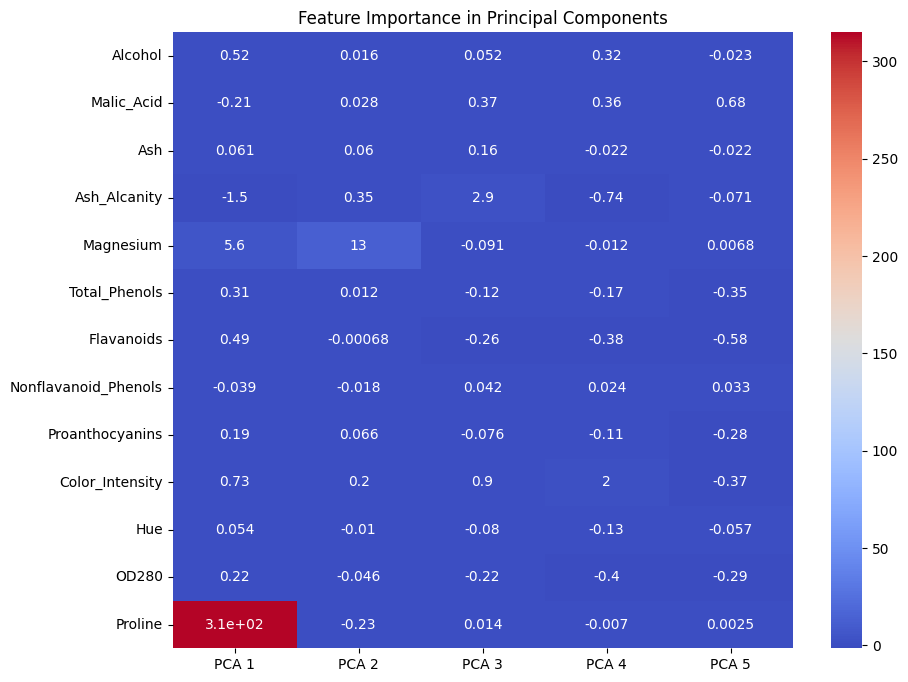

In [12]:
loadings = pca_opt.components_.T * np.sqrt(pca_opt.explained_variance_)
print("Loadings:")
print(loadings)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PCA 1', 'PCA 2', 'PCA 3', 'PCA 4', 'PCA 5'], yticklabels=features)
plt.title('Feature Importance in Principal Components')
plt.show()

In [13]:
num_cluster = [ c for c in range(2,10)]
inertias = kmeans_inertias(num_cluster, X_pca)
print(kmeans_inertias(num_cluster, X_pca))

[4545477.262338655, 2370426.651278643, 1550839.512464701, 987981.7083729705, 647067.6209923457, 414497.0450443452, 322958.92485430243, 283524.67094408674]


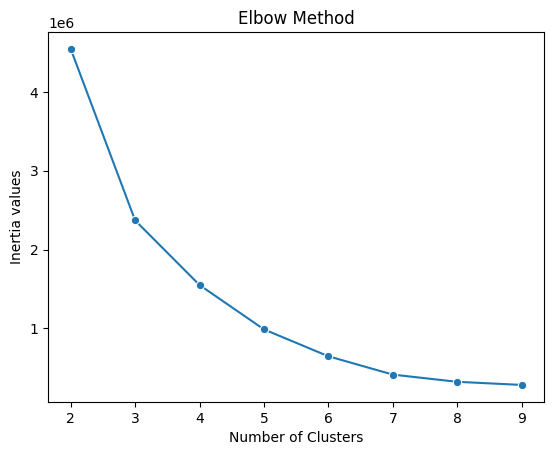

In [14]:
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia values')
sns.lineplot(x = num_cluster, y=inertias, marker='o')
plt.show()

In [15]:
def kmeans_silhouettes(num_cluster, df_pca):
    sils = []
    for c in num_cluster:
        km = KMeans(n_clusters=c, random_state=0).fit(df_pca)
        sils.append(silhouette_score(df_pca,km.labels_))
    return sils

In [16]:
silhoettes = kmeans_silhouettes(num_cluster, X_pca)
print(silhoettes)

[0.6555543416185573, 0.5712371867493663, 0.545125463854883, 0.5478529424100043, 0.5658329888702294, 0.5577420185735579, 0.5410909471500324, 0.5215329780387292]


In [17]:
kmeans= KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_pca)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


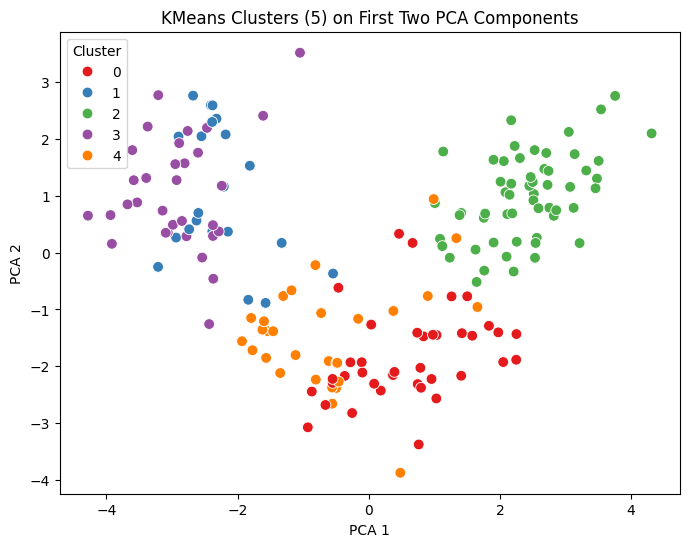

In [18]:
# Perform PCA to get 5 components (if not already done)
pca = PCA(n_components=5)
pca_data = pca.fit_transform(df_scaled)

# KMeans clustering with 5 clusters
kmeans_5 = KMeans(n_clusters=5, random_state=0)
labels_5 = kmeans_5.fit_predict(pca_data)

# Plot first two PCA components colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=labels_5, palette='Set1', s=60)
plt.title('KMeans Clusters (5) on First Two PCA Components')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


# # Plot first two PCA components colored by cluster
# plt.figure(figsize=(8,6))
# sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='Set1', s=60)
# plt.title('KMeans Clusters on First Two PCA Components')
# plt.xlabel('PCA 1')
# plt.ylabel('PCA 2')
# plt.legend(title='Cluster')
# plt.show()

# # Optionally, plot pairplot for first 5 PCA components
# import pandas as pd
# pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])
# pca_df['Cluster'] = labels
# sns.pairplot(pca_df, hue='Cluster', palette='Set1')
# plt.suptitle('Pairplot of 5 PCA Components Colored by Cluster', y=1.02)
# plt.show()

In [19]:

# Plot first two PCA components colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='Set1', s=60)
plt.title('KMeans Clusters on First Two PCA Components')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()

# Optionally, plot pairplot for first 5 PCA components
import pandas as pd
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(5)])
pca_df['Cluster'] = labels
sns.pairplot(pca_df, hue='Cluster', palette='Set1')
plt.suptitle('Pairplot of 5 PCA Components Colored by Cluster', y=1.02)
plt.show()

NameError: name 'labels' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
from sklearn.preprocessing import scale
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

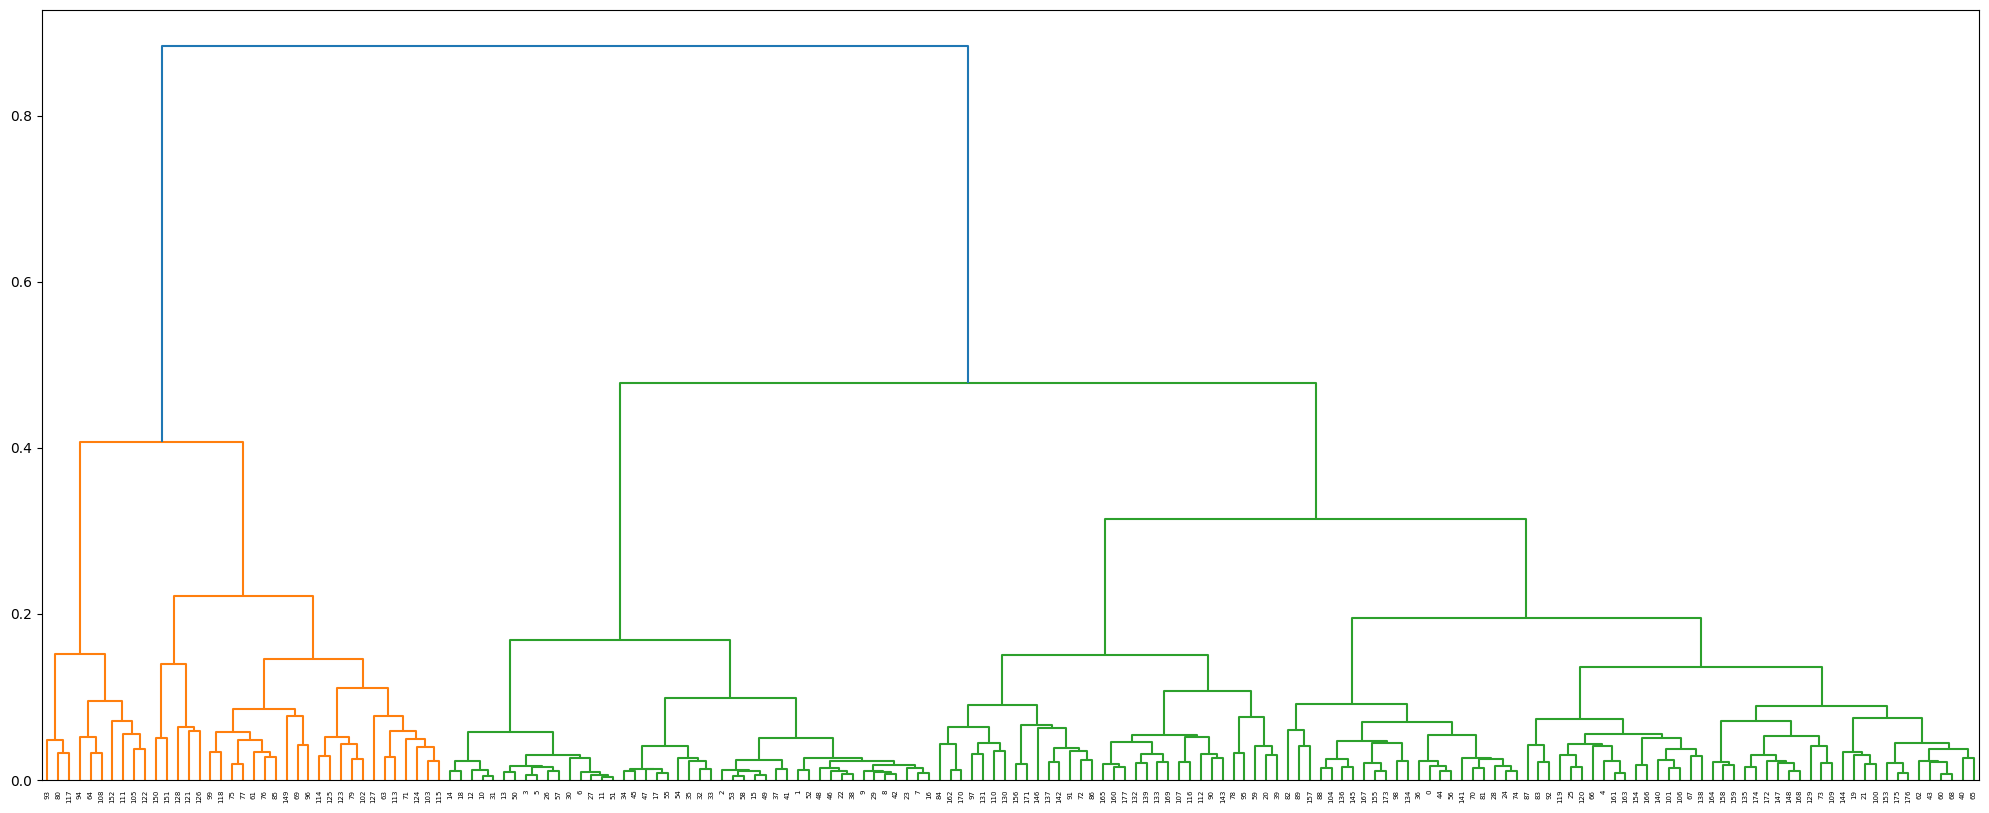

In [ ]:
df[['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']] = scale(df[['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']], axis=1)
X = df[['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']]
Z = linkage(X, 'complete')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z, labels=df.index.tolist())

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Select features for clustering
features = df.select_dtypes(include=[float, int]).columns
X = df[features]

# Compute linkage matrix
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(25,10))
dendrogram(Z, labels=df.index.tolist())
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

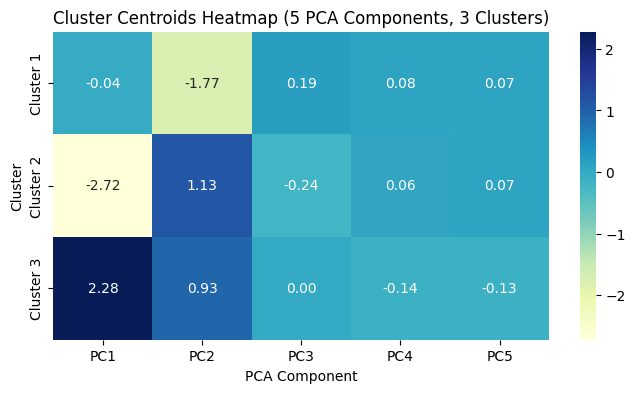

In [ ]:
# Heatmap of cluster centroids for all 5 PCA components (3 clusters)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Perform PCA to get 5 components
pca = PCA(n_components=5)
pca_data = pca.fit_transform(df_scaled)

# KMeans clustering with 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=0)
labels_3 = kmeans_3.fit_predict(pca_data)

# Get cluster centroids
centroids = kmeans_3.cluster_centers_

# Create a DataFrame for centroids
centroids_df = pd.DataFrame(centroids, columns=[f'PC{i+1}' for i in range(5)])
centroids_df.index = [f'Cluster {i}' for i in range(1, 4)]

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(centroids_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Centroids Heatmap (5 PCA Components, 3 Clusters)')
plt.ylabel('Cluster')
plt.xlabel('PCA Component')
plt.show()